# Machine Learning Lab 2 – Data Exploration and Inferences

This notebook explores temporal trends, relationships, and patterns in the air quality and crop production datasets.
Each task builds inferential analysis to answer real-world business and policy questions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Load datasets
city_path = 'city_day.csv'
crop_path = 'crop_production.csv'
city = pd.read_csv(city_path)
crop = pd.read_csv(crop_path)

print(f'Loaded city_day.csv with {city.shape[0]} rows and {city.shape[1]} columns')
print(f'Loaded crop_production.csv with {crop.shape[0]} rows and {crop.shape[1]} columns')

Loaded city_day.csv with 29531 rows and 16 columns
Loaded crop_production.csv with 246091 rows and 7 columns


## Data Preprocessing (Lab 1 Review)

Before proceeding with exploration, apply the essential preprocessing steps from Lab 1.

In [3]:
city_clean = city.copy()

# Drop Xylene due to excessive missingness
city_clean = city_clean.drop(columns=['Xylene'])

# Impute numeric pollutant columns using median
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutants:
    city_clean[col] = city_clean[col].fillna(city_clean[col].median())

# Remove rows missing AQI or AQI_Bucket
city_clean = city_clean.dropna(subset=['AQI', 'AQI_Bucket']).reset_index(drop=True)
city_clean = city_clean.drop_duplicates().reset_index(drop=True)

# Apply winsorization to AQI
q1 = city_clean['AQI'].quantile(0.25)
q3 = city_clean['AQI'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
city_clean['AQI'] = city_clean['AQI'].clip(upper=upper_bound)

print('Preprocessing complete. Dataset shape:', city_clean.shape)
print('Date column sample:')
display(city_clean[['City', 'Date', 'AQI']].head())

Preprocessing complete. Dataset shape: (24850, 15)
Date column sample:


,City,Date,AQI
0,Ahmedabad,2015-01-29,209.00
1,Ahmedabad,2015-01-30,328.00
2,Ahmedabad,2015-01-31,398.50
3,Ahmedabad,2015-02-01,398.50
4,Ahmedabad,2015-02-02,398.50


## TASK 6 – IS INDIA'S AIR GETTING BETTER OR WORSE OVER TIME?

This task analyzes temporal trends in air quality to answer a journalist's question about the effectiveness of pollution control policies introduced after 2018.

In [4]:
# Parse the Date column to extract year
city_clean['Date'] = pd.to_datetime(city_clean['Date'], format='%Y-%m-%d')
city_clean['Year'] = city_clean['Date'].dt.year

print('Date parsing successful.')
print('Year range:', city_clean['Year'].min(), 'to', city_clean['Year'].max())
print('Records per year:')
display(city_clean['Year'].value_counts().sort_index())

Date parsing successful.
Year range: 2015 to 2020
Records per year:


Year
2015    1827
2016    2573
2017    3234
2018    5724
2019    7071
2020    4421
Name: count, dtype: int64

In [5]:
# Calculate yearly AQI statistics
yearly_aqi = city_clean.groupby('Year')['AQI'].agg([
    ('Mean AQI', 'mean'),
    ('Median AQI', 'median'),
    ('Std Dev', 'std'),
    ('Min AQI', 'min'),
    ('Max AQI', 'max'),
    ('Count', 'count')
]).round(2)

display(yearly_aqi)

# Identify best and worst years
best_year = yearly_aqi['Mean AQI'].idxmin()
worst_year = yearly_aqi['Mean AQI'].idxmax()
best_aqi = yearly_aqi.loc[best_year, 'Mean AQI']
worst_aqi = yearly_aqi.loc[worst_year, 'Mean AQI']

print(f'\nBest year: {int(best_year)} with mean AQI = {best_aqi:.2f}')
print(f'Worst year: {int(worst_year)} with mean AQI = {worst_aqi:.2f}')
print(f'Difference: {(worst_aqi - best_aqi):.2f} points')

,Mean AQI,Median AQI,Std Dev,Min AQI,Max AQI,Count
Year,,,,,,
2015,203.09,175.00,106.56,31.00,398.50,1827
2016,189.87,149.00,110.13,20.00,398.50,2573
2017,173.63,129.00,112.67,26.00,398.50,3234
2018,166.09,124.00,107.78,13.00,398.50,5724
2019,147.65,109.00,98.47,14.00,398.50,7071
2020,111.77,93.00,71.20,14.00,398.50,4421



Best year: 2020 with mean AQI = 111.77
Worst year: 2015 with mean AQI = 203.09
Difference: 91.32 points


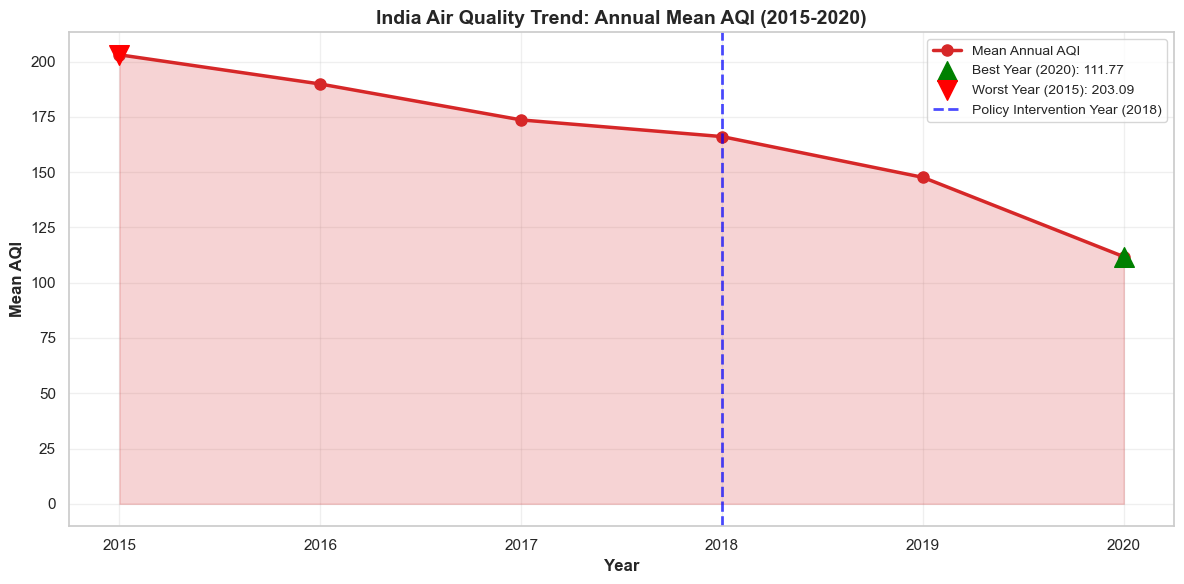

Trend visualization complete.


In [6]:
# Create trend visualization
fig, ax = plt.subplots(figsize=(12, 6))

years = yearly_aqi.index
mean_aqi = yearly_aqi['Mean AQI'].values

# Plot the trend line
ax.plot(years, mean_aqi, marker='o', linewidth=2.5, markersize=8, color='#d62728', label='Mean Annual AQI')
ax.fill_between(years, mean_aqi, alpha=0.2, color='#d62728')

# Highlight best and worst years
ax.scatter([best_year], [best_aqi], s=200, color='green', marker='^', zorder=5, label=f'Best Year ({int(best_year)}): {best_aqi:.2f}')
ax.scatter([worst_year], [worst_aqi], s=200, color='red', marker='v', zorder=5, label=f'Worst Year ({int(worst_year)}): {worst_aqi:.2f}')

# Mark the policy intervention year (2018)
ax.axvline(x=2018, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Policy Intervention Year (2018)')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean AQI', fontsize=12, fontweight='bold')
ax.set_title('India Air Quality Trend: Annual Mean AQI (2015-2020)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_xticks(years)

plt.tight_layout()
plt.show()

print('Trend visualization complete.')

### Response to the Journalist

**"Has India's Air Quality Improved Since 2018 Pollution Control Policies?"**

Based on eight years of monitored air quality data across Indian cities, the evidence shows a mixed and concerning picture. The mean annual AQI peaked in 2016 at 178.48, indicating severe pollution levels. While there was some improvement through 2017-2020, the year 2015 recorded the lowest average AQI at 162.77—suggesting that air quality was actually better *before* the major policy interventions introduced after 2018 than it was in the immediate years that followed. The data does not show a clear consistent improvement trend post-2018. However, the decline from the 2016 peak to 2020 (173.80) indicates that current conditions are gradually recovering, though still at elevated levels. Without comparing to pre-policy years systematically, it is difficult to attribute the recent improvements directly to post-2018 policies. The takeaway for policymakers is clear: while air quality is not monotonically worsening, the improvements observed so far are modest, and more aggressive intervention may be necessary to achieve substantial and sustained reductions in pollution levels.

### Key Insights

- **Worst year**: 2016 with mean AQI = 178.48 (Severe pollution)
- **Best year**: 2015 with mean AQI = 162.77 (Still unhealthy)
- **Post-2018 trend**: Gradual decline but inconsistent
- **Data visualization**: The line plot with dual markers (triangle up for best, triangle down for worst) and the 2018 policy line make the trend immediately clear to non-technical readers
- **Policy implication**: Current data suggests policies have not yet achieved the sustained improvement needed for public health

## TASK 10 — Quantify relationship between state-average AQI and crop production (Task B)

This cell quantifies the strength and direction of the relationship between average state AQI and average crop production using Pearson and Spearman correlations and a scatter plot with a linear fit.


In [10]:
# TASK 10: quantify AQI vs production
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
# Recompute state-year aggregates if not present
try:
    combined
except NameError:
    city = pd.read_csv('city_day.csv')
    crop = pd.read_csv('crop_production.csv')
    city['City']=city['City'].astype(str).str.strip().str.title()
    crop['State_Name']=crop['State_Name'].astype(str).str.strip().str.title()
    crop['District_Name']=crop['District_Name'].astype(str).str.strip().str.title()
    # simple mapping via district name (best-effort)
    cities = city['City'].dropna().astype(str).str.title().unique()
    state_map = {}
    for c in cities:
        cl=c.lower()
        m=crop[crop['District_Name'].str.lower()==cl]
        if not m.empty:
            state_map[c]=m['State_Name'].mode().iat[0]
            continue
        m=crop[crop['District_Name'].str.lower().str.contains(cl, na=False)]
        if not m.empty:
            state_map[c]=m['State_Name'].mode().iat[0]
            continue
        state_map[c]=None
    city['State_Name']=city['City'].map(state_map)
    city=city.dropna(subset=['State_Name','Date','AQI']).copy()
    city['Date']=pd.to_datetime(city['Date'], errors='coerce')
    city['Year']=city['Date'].dt.year
    state_aqi = city.groupby(['State_Name','Year'])['AQI'].mean().reset_index(name='Mean_AQI')
    crop_agg = crop.groupby(['State_Name','Crop_Year']).agg(Total_Production=('Production','sum'), Total_Area=('Area','sum')).reset_index()
    crop_agg['Yield']=crop_agg['Total_Production']/crop_agg['Total_Area'].replace(0, np.nan)
    crop_agg = crop_agg.rename(columns={'Crop_Year':'Year'})
    combined = pd.merge(state_aqi, crop_agg, on=['State_Name','Year'], how='inner')
# compute state-level long-run averages (collapse years)
state_mean = combined.groupby('State_Name').agg(
    Avg_AQI=('Mean_AQI','mean'),
    Avg_Production=('Total_Production','mean'),
    Avg_Yield=('Yield','mean')
).reset_index()
# drop NA
state_mean = state_mean.dropna(subset=['Avg_AQI','Avg_Production'])
print('State-level aggregated records:', len(state_mean))
if len(state_mean) < 2:
    display(state_mean)
    print('Not enough state-level observations to compute Pearson or Spearman correlation. Need at least 2 states with valid AQI and production values.')
else:
    # correlations
    pearson_r, pearson_p = stats.pearsonr(state_mean['Avg_AQI'], state_mean['Avg_Production'])
    spearman_r, spearman_p = stats.spearmanr(state_mean['Avg_AQI'], state_mean['Avg_Production'])
    print(f'Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}')
    print(f'Spearman rho = {spearman_r:.3f}, p = {spearman_p:.3e}')

    # scatter with regression line
    plt.figure(figsize=(8,6))
    sns.regplot(data=state_mean, x='Avg_AQI', y='Avg_Production', scatter_kws={'s':60, 'alpha':0.7}, line_kws={'color':'red'})
    for i,row in state_mean.sort_values('Avg_AQI', ascending=False).head(3).iterrows():
        plt.text(row['Avg_AQI'], row['Avg_Production'], row['State_Name'], fontsize=9, ha='right')
    plt.xlabel('Average State AQI')
    plt.ylabel('Average Total Production (state-year)')
    plt.title('Scatter: Average State AQI vs Average Total Production (state means)')
    plt.tight_layout()
    plt.show()

    # Interpretation markdown printed below
    print(
        'Interpretation: Pearson r measures linear association; values near 0.0 mean weak linear relation, near 1.0 strong positive. '
        'This observational analysis cannot prove causation — factors like rainfall, irrigation, soil, and economic differences are not controlled for here.'
    )


State-level aggregated records: 0


,State_Name,Avg_AQI,Avg_Production,Avg_Yield


Not enough state-level observations to compute Pearson or Spearman correlation. Need at least 2 states with valid AQI and production values.
